In [1]:
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import ops
from tensorflow import data as tf_data


SEED = 42
keras.utils.set_random_seed(SEED)

In [2]:

BATCH_SIZE = 128
BUFFER_SIZE = BATCH_SIZE * 2
AUTO = tf_data.AUTOTUNE
INPUT_SHAPE = (32, 32, 3)
NUM_CLASSES = 10  # for CIFAR 10


IMAGE_SIZE = 48


DIMENSIONS = 256
SE_RATIO = 8
TRUNK_DEPTH = 2


LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4


EPOCHS = 50

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
(x_train, y_train), (x_val, y_val) = (
    (x_train[:40000], y_train[:40000]),
    (x_train[40000:], y_train[40000:]),
)
print(f"Training samples: {len(x_train)}")
print(f"Validation samples: {len(x_val)}")
print(f"Testing samples: {len(x_test)}")

train_ds = tf_data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(AUTO)

val_ds = tf_data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTO)

test_ds = tf_data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTO)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training samples: 40000
Validation samples: 10000
Testing samples: 10000


In [4]:
def get_preprocessing():
    model = keras.Sequential(
        [
            layers.Rescaling(1 / 255.0),
            layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
        ],
        name="preprocessing",
    )
    return model


def get_train_augmentation_model():
    model = keras.Sequential(
        [
            layers.Rescaling(1 / 255.0),
            layers.Resizing(INPUT_SHAPE[0] + 20, INPUT_SHAPE[0] + 20),
            layers.RandomCrop(IMAGE_SIZE, IMAGE_SIZE),
            layers.RandomFlip("horizontal"),
        ],
        name="train_data_augmentation",
    )
    return model

In [5]:
def build_convolutional_stem(dimensions):

    config = {
        "kernel_size": (3, 3),
        "strides": (2, 2),
        "activation": ops.gelu,
        "padding": "same",
    }

    convolutional_stem = keras.Sequential(
        [
            layers.Conv2D(filters=dimensions // 2, **config),
            layers.Conv2D(filters=dimensions, **config),
        ],
        name="convolutional_stem",
    )

    return convolutional_stem

In [6]:
class SqueezeExcite(layers.Layer):


    def __init__(self, ratio, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

    def build(self, input_shape):
        filters = input_shape[-1]
        self.squeeze = layers.GlobalAveragePooling2D(keepdims=True)
        self.reduction = layers.Dense(
            units=filters // self.ratio,
            activation="relu",
            use_bias=False,
        )
        self.excite = layers.Dense(units=filters, activation="sigmoid", use_bias=False)
        self.multiply = layers.Multiply()

    def call(self, x):
        shortcut = x
        x = self.squeeze(x)
        x = self.reduction(x)
        x = self.excite(x)
        x = self.multiply([shortcut, x])
        return x


class Trunk(layers.Layer):


    def __init__(self, depth, dimensions, ratio, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.dimensions = dimensions
        self.depth = depth

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "ratio": self.ratio,
                "dimensions": self.dimensions,
                "depth": self.depth,
            }
        )
        return config

    def build(self, input_shape):
        config = {
            "filters": self.dimensions,
            "activation": ops.gelu,
            "padding": "same",
        }

        trunk_block = [
            layers.LayerNormalization(epsilon=1e-6),
            layers.Conv2D(kernel_size=(1, 1), **config),
            layers.Conv2D(kernel_size=(3, 3), **config),
            SqueezeExcite(ratio=self.ratio),
            layers.Conv2D(kernel_size=(1, 1), filters=self.dimensions, padding="same"),
        ]

        self.trunk_blocks = [keras.Sequential(trunk_block) for _ in range(self.depth)]
        self.add = layers.Add()
        self.flatten_spatial = layers.Reshape((-1, self.dimensions))

    def call(self, x):
        # Remember the input.
        shortcut = x
        for trunk_block in self.trunk_blocks:
            output = trunk_block(x)
            shortcut = self.add([output, shortcut])
            x = shortcut
        # Flatten the patches.
        x = self.flatten_spatial(x)
        return x

In [7]:
class AttentionPooling(layers.Layer):


    def __init__(self, dimensions, num_classes, **kwargs):
        super().__init__(**kwargs)
        self.dimensions = dimensions
        self.num_classes = num_classes
        self.cls = keras.Variable(ops.zeros((1, 1, dimensions)))

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "dimensions": self.dimensions,
                "num_classes": self.num_classes,
                "cls": self.cls.numpy(),
            }
        )
        return config

    def build(self, input_shape):
        self.attention = layers.MultiHeadAttention(
            num_heads=1,
            key_dim=self.dimensions,
            dropout=0.2,
        )
        self.layer_norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential(
            [
                layers.Dense(units=self.dimensions, activation=ops.gelu),
                layers.Dropout(0.2),
                layers.Dense(units=self.dimensions, activation=ops.gelu),
            ]
        )
        self.dense = layers.Dense(units=self.num_classes)
        self.flatten = layers.Flatten()

    def call(self, x):
        batch_size = ops.shape(x)[0]

        class_token = ops.repeat(self.cls, repeats=batch_size, axis=0)

        x = ops.concatenate([class_token, x], axis=1)

        x = self.layer_norm1(x)
        x, viz_weights = self.attention(
            query=x[:, 0:1], key=x, value=x, return_attention_scores=True
        )
        class_token = class_token + x
        class_token = self.layer_norm2(class_token)
        class_token = self.flatten(class_token)
        class_token = self.layer_norm3(class_token)
        class_token = class_token + self.mlp(class_token)

        logits = self.dense(class_token)
        return logits, ops.squeeze(viz_weights)[..., 1:]

In [8]:

test_images, test_labels = next(iter(test_ds))


class TrainMonitor(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 4:
            test_augmented_images = self.model.preprocessing_model(test_images)

            test_x = self.model.stem(test_augmented_images)

            test_x = self.model.trunk(test_x)

            _, test_viz_weights = self.model.attention_pooling(test_x)

            num_patches = ops.shape(test_viz_weights)[-1]
            height = width = int(math.sqrt(num_patches))
            test_viz_weights = layers.Reshape((height, width))(test_viz_weights)

            index = np.random.randint(low=0, high=ops.shape(test_augmented_images)[0])
            selected_image = test_augmented_images[index]
            selected_weight = test_viz_weights[index]

            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
            ax[0].imshow(selected_image)
            ax[0].set_title(f"Original: {epoch:03d}")
            ax[0].axis("off")
            img = ax[1].imshow(selected_image)
            ax[1].imshow(
                selected_weight, cmap="inferno", alpha=0.6, extent=img.get_extent()
            )
            ax[1].set_title(f"Attended: {epoch:03d}")
            ax[1].axis("off")
            plt.axis("off")
            plt.show()
            plt.close()

In [9]:
class WarmUpCosine(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(
        self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps
    ):
        super().__init__()
        self.learning_rate_base = learning_rate_base
        self.total_steps = total_steps
        self.warmup_learning_rate = warmup_learning_rate
        self.warmup_steps = warmup_steps
        self.pi = np.pi

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("Total_steps must be larger or equal to warmup_steps.")
        cos_annealed_lr = ops.cos(
            self.pi
            * (ops.cast(step, "float32") - self.warmup_steps)
            / float(self.total_steps - self.warmup_steps)
        )
        learning_rate = 0.5 * self.learning_rate_base * (1 + cos_annealed_lr)
        if self.warmup_steps > 0:
            if self.learning_rate_base < self.warmup_learning_rate:
                raise ValueError(
                    "Learning_rate_base must be larger or equal to "
                    "warmup_learning_rate."
                )
            slope = (
                self.learning_rate_base - self.warmup_learning_rate
            ) / self.warmup_steps
            warmup_rate = slope * ops.cast(step, "float32") + self.warmup_learning_rate
            learning_rate = ops.where(
                step < self.warmup_steps, warmup_rate, learning_rate
            )
        return ops.where(
            step > self.total_steps,
            0.0,
            learning_rate,
        )


total_steps = int((len(x_train) / BATCH_SIZE) * EPOCHS)
warmup_epoch_percentage = 0.15
warmup_steps = int(total_steps * warmup_epoch_percentage)
scheduled_lrs = WarmUpCosine(
    learning_rate_base=LEARNING_RATE,
    total_steps=total_steps,
    warmup_learning_rate=0.0,
    warmup_steps=warmup_steps,
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'patch_conv_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 121ms/step - accuracy: 0.2639 - loss: 1.9500 - top-5-accuracy: 0.7889 - val_accuracy: 0.3513 - val_loss: 1.7034 - val_top-5-accuracy: 0.8941
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.4157 - loss: 1.5629 - top-5-accuracy: 0.9079 - val_accuracy: 0.4664 - val_loss: 1.4359 - val_top-5-accuracy: 0.9274
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.5020 - loss: 1.3572 - top-5-accuracy: 0.9357 - val_accuracy: 0.5416 - val_loss: 1.2863 - val_top-5-accuracy: 0.9415
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.5719 - loss: 1.1887 - top-5-accuracy: 0.9523 - val_accuracy: 0.5812 - val_loss: 1.1408 - val_top-5-accuracy: 0.9625
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.6192 - loss: 1.0758 - top-5-accuracy: 0.9628

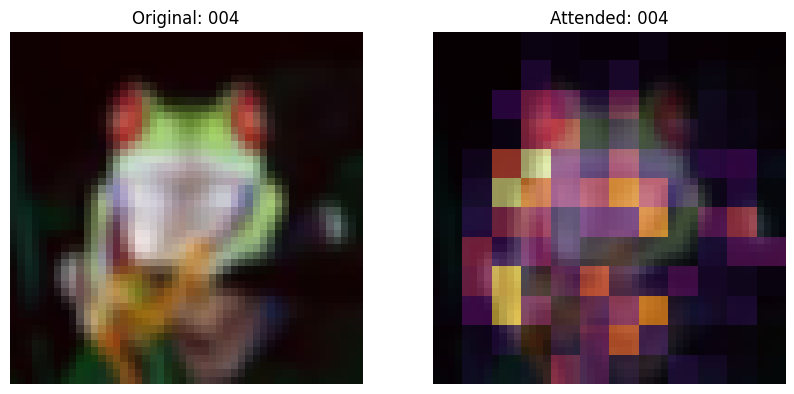

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.6291 - loss: 1.0436 - top-5-accuracy: 0.9657 - val_accuracy: 0.6370 - val_loss: 1.0108 - val_top-5-accuracy: 0.9677
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - accuracy: 0.6686 - loss: 0.9315 - top-5-accuracy: 0.9722 - val_accuracy: 0.6235 - val_loss: 1.0492 - val_top-5-accuracy: 0.9689
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.7041 - loss: 0.8381 - top-5-accuracy: 0.9791 - val_accuracy: 0.6682 - val_loss: 0.9646 - val_top-5-accuracy: 0.9671
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.7290 - loss: 0.7705 - top-5-accuracy: 0.9819 - val_accuracy: 0.7306 - val_loss: 0.7648 - val_top-5-accuracy: 0.9848
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.7524 - loss: 0.7067 - top-5-accuracy: 0.9848 - val_accuracy: 0.7563 - val_loss: 0.6971 - val_top-5-accuracy: 0.9845
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.7679 - loss: 0.66

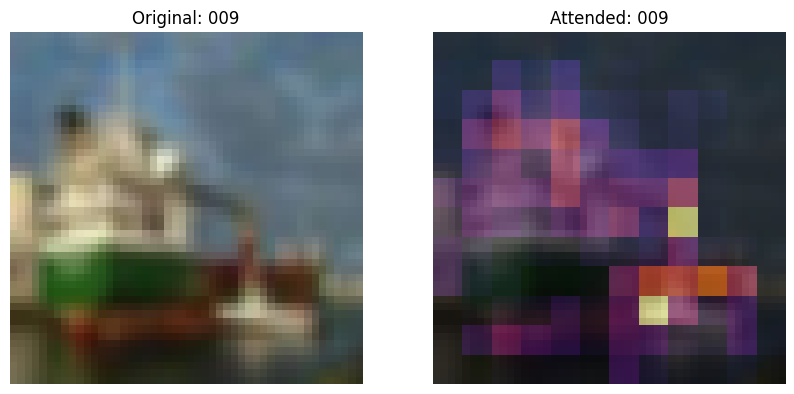

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.7708 - loss: 0.6573 - top-5-accuracy: 0.9874 - val_accuracy: 0.7786 - val_loss: 0.6415 - val_top-5-accuracy: 0.9861
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.7914 - loss: 0.5999 - top-5-accuracy: 0.9894 - val_accuracy: 0.7661 - val_loss: 0.6803 - val_top-5-accuracy: 0.9844
Epoch 12/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.8008 - loss: 0.5694 - top-5-accuracy: 0.9902 - val_accuracy: 0.7903 - val_loss: 0.6213 - val_top-5-accuracy: 0.9884
Epoch 13/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.8139 - loss: 0.5351 - top-5-accuracy: 0.9909 - val_accuracy: 0.8053 - val_loss: 0.5702 - val_top-5-accuracy: 0.9899
Epoch 14/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.8246 - loss: 0.5051 - top-5-accuracy: 0.9923 - val_accuracy: 0.7995 - val_loss: 0.5890 - val_top-5-accuracy: 0.9894
Epoch 15/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8286 - loss: 

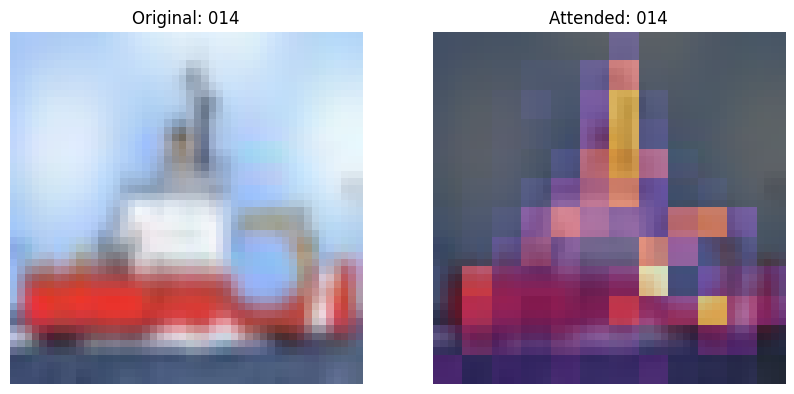

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8307 - loss: 0.4863 - top-5-accuracy: 0.9927 - val_accuracy: 0.8029 - val_loss: 0.5771 - val_top-5-accuracy: 0.9901
Epoch 16/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8391 - loss: 0.4630 - top-5-accuracy: 0.9942 - val_accuracy: 0.8139 - val_loss: 0.5465 - val_top-5-accuracy: 0.9896
Epoch 17/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.8466 - loss: 0.4373 - top-5-accuracy: 0.9942 - val_accuracy: 0.8195 - val_loss: 0.5454 - val_top-5-accuracy: 0.9902
Epoch 18/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8529 - loss: 0.4174 - top-5-accuracy: 0.9954 - val_accuracy: 0.8262 - val_loss: 0.5253 - val_top-5-accuracy: 0.9900
Epoch 19/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8636 - loss: 0.3918 - top-5-accuracy: 0.9958 - val_accuracy: 0.8272 - val_loss: 0.5262 - val_top-5-accuracy: 0.9917
Epoch 20/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8653 - loss: 

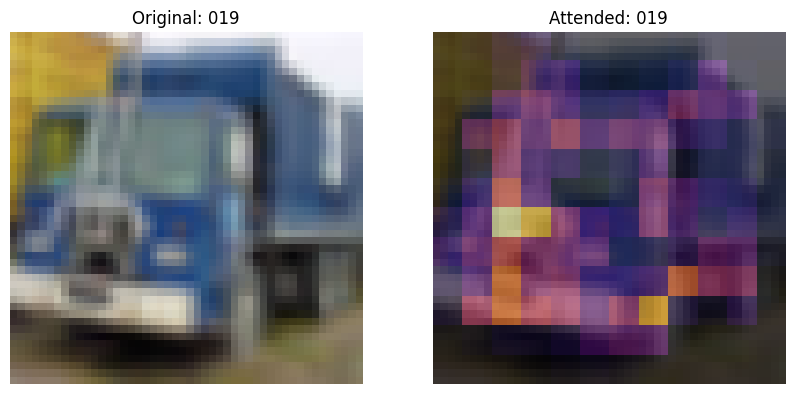

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8667 - loss: 0.3776 - top-5-accuracy: 0.9955 - val_accuracy: 0.8215 - val_loss: 0.5486 - val_top-5-accuracy: 0.9907
Epoch 21/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8735 - loss: 0.3574 - top-5-accuracy: 0.9968 - val_accuracy: 0.8284 - val_loss: 0.5181 - val_top-5-accuracy: 0.9911
Epoch 22/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8852 - loss: 0.3326 - top-5-accuracy: 0.9965 - val_accuracy: 0.8312 - val_loss: 0.5237 - val_top-5-accuracy: 0.9927
Epoch 23/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8835 - loss: 0.3301 - top-5-accuracy: 0.9972 - val_accuracy: 0.8349 - val_loss: 0.4966 - val_top-5-accuracy: 0.9921
Epoch 24/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8970 - loss: 0.2986 - top-5-accuracy: 0.9979 - val_accuracy: 0.8346 - val_loss: 0.5185 - val_top-5-accuracy: 0.9916
Epoch 25/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8985 - loss: 

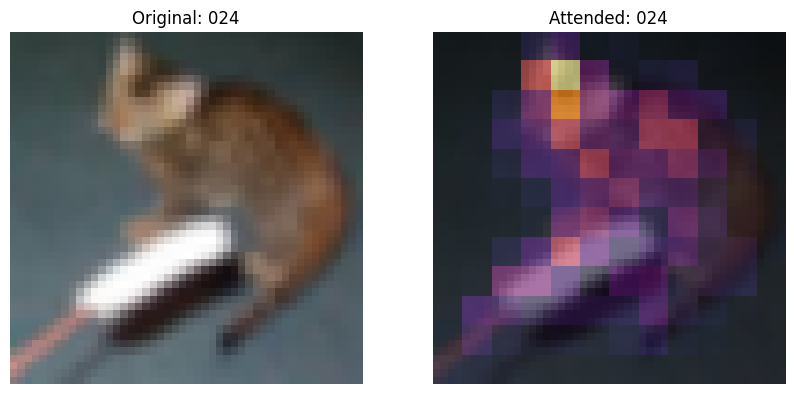

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9007 - loss: 0.2846 - top-5-accuracy: 0.9982 - val_accuracy: 0.8398 - val_loss: 0.4987 - val_top-5-accuracy: 0.9921
Epoch 26/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9075 - loss: 0.2637 - top-5-accuracy: 0.9982 - val_accuracy: 0.8385 - val_loss: 0.5235 - val_top-5-accuracy: 0.9907
Epoch 27/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9109 - loss: 0.2515 - top-5-accuracy: 0.9982 - val_accuracy: 0.8452 - val_loss: 0.5309 - val_top-5-accuracy: 0.9917
Epoch 28/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9188 - loss: 0.2307 - top-5-accuracy: 0.9987 - val_accuracy: 0.8410 - val_loss: 0.5165 - val_top-5-accuracy: 0.9923
Epoch 29/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9219 - loss: 0.2171 - top-5-accuracy: 0.9990 - val_accuracy: 0.8417 - val_loss: 0.5383 - val_top-5-accuracy: 0.9936
Epoch 30/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9271 - loss: 

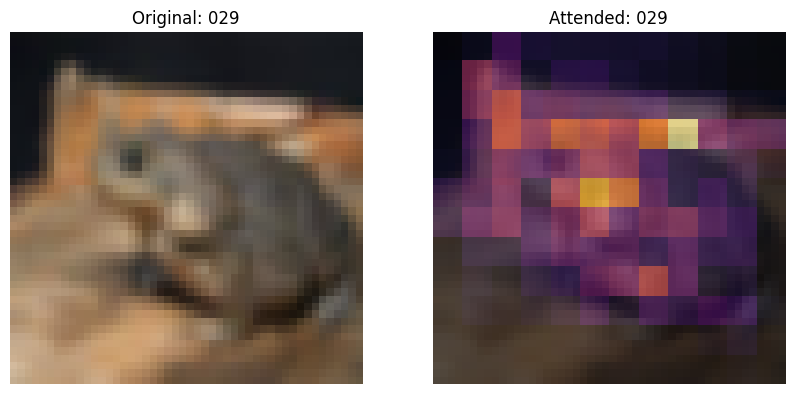

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9271 - loss: 0.2070 - top-5-accuracy: 0.9992 - val_accuracy: 0.8490 - val_loss: 0.4969 - val_top-5-accuracy: 0.9926
Epoch 31/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9355 - loss: 0.1843 - top-5-accuracy: 0.9991 - val_accuracy: 0.8463 - val_loss: 0.5108 - val_top-5-accuracy: 0.9920
Epoch 32/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9384 - loss: 0.1748 - top-5-accuracy: 0.9995 - val_accuracy: 0.8491 - val_loss: 0.5582 - val_top-5-accuracy: 0.9919
Epoch 33/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9435 - loss: 0.1596 - top-5-accuracy: 0.9995 - val_accuracy: 0.8548 - val_loss: 0.5256 - val_top-5-accuracy: 0.9922
Epoch 34/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9489 - loss: 0.1473 - top-5-accuracy: 0.9996 - val_accuracy: 0.8510 - val_loss: 0.5770 - val_top-5-accuracy: 0.9931
Epoch 35/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9533 - loss: 

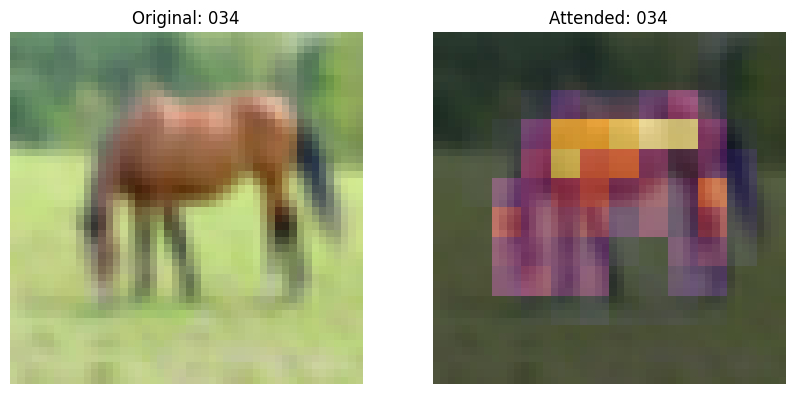

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9535 - loss: 0.1305 - top-5-accuracy: 0.9996 - val_accuracy: 0.8522 - val_loss: 0.5612 - val_top-5-accuracy: 0.9927
Epoch 36/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9583 - loss: 0.1182 - top-5-accuracy: 0.9998 - val_accuracy: 0.8515 - val_loss: 0.5655 - val_top-5-accuracy: 0.9920
Epoch 37/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9641 - loss: 0.1030 - top-5-accuracy: 0.9999 - val_accuracy: 0.8597 - val_loss: 0.5564 - val_top-5-accuracy: 0.9928
Epoch 38/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9666 - loss: 0.0937 - top-5-accuracy: 1.0000 - val_accuracy: 0.8627 - val_loss: 0.5587 - val_top-5-accuracy: 0.9931
Epoch 39/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9697 - loss: 0.0851 - top-5-accuracy: 0.9999 - val_accuracy: 0.8628 - val_loss: 0.5505 - val_top-5-accuracy: 0.9929
Epoch 40/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9724 - loss: 

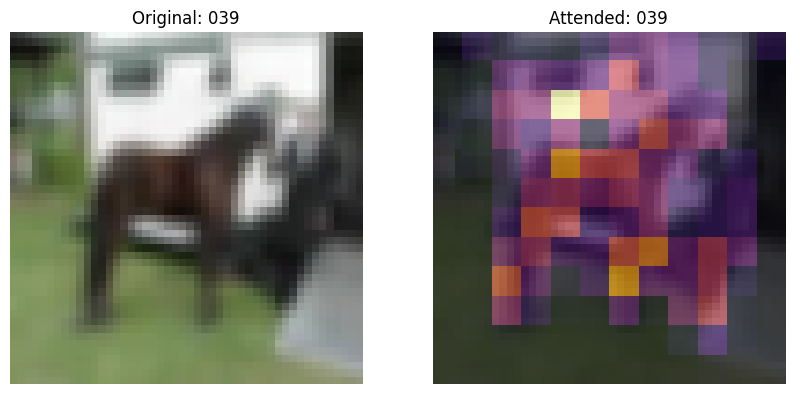

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9721 - loss: 0.0788 - top-5-accuracy: 0.9999 - val_accuracy: 0.8613 - val_loss: 0.5610 - val_top-5-accuracy: 0.9929
Epoch 41/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9761 - loss: 0.0680 - top-5-accuracy: 1.0000 - val_accuracy: 0.8629 - val_loss: 0.5604 - val_top-5-accuracy: 0.9935
Epoch 42/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9789 - loss: 0.0614 - top-5-accuracy: 0.9999 - val_accuracy: 0.8634 - val_loss: 0.5816 - val_top-5-accuracy: 0.9942
Epoch 43/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9806 - loss: 0.0547 - top-5-accuracy: 0.9999 - val_accuracy: 0.8659 - val_loss: 0.5777 - val_top-5-accuracy: 0.9927
Epoch 44/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9829 - loss: 0.0511 - top-5-accuracy: 1.0000 - val_accuracy: 0.8653 - val_loss: 0.5772 - val_top-5-accuracy: 0.9938
Epoch 45/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9834 - loss: 

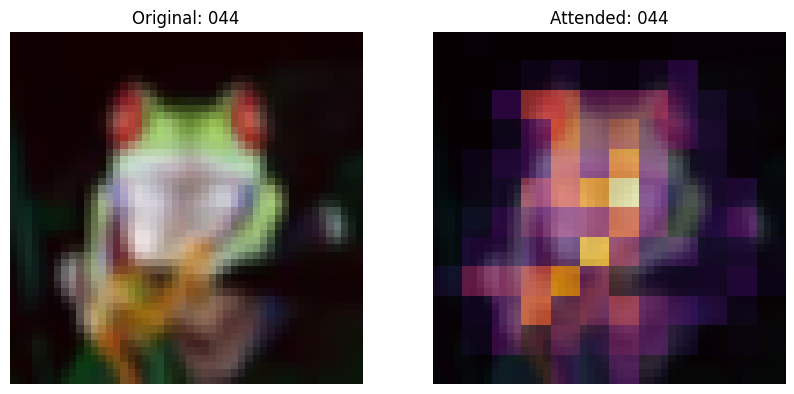

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9833 - loss: 0.0472 - top-5-accuracy: 1.0000 - val_accuracy: 0.8669 - val_loss: 0.5740 - val_top-5-accuracy: 0.9939
Epoch 46/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9859 - loss: 0.0416 - top-5-accuracy: 1.0000 - val_accuracy: 0.8670 - val_loss: 0.5815 - val_top-5-accuracy: 0.9946
Epoch 47/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9861 - loss: 0.0391 - top-5-accuracy: 1.0000 - val_accuracy: 0.8672 - val_loss: 0.5831 - val_top-5-accuracy: 0.9942
Epoch 48/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9865 - loss: 0.0393 - top-5-accuracy: 1.0000 - val_accuracy: 0.8678 - val_loss: 0.5816 - val_top-5-accuracy: 0.9939
Epoch 49/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9869 - loss: 0.0389 - top-5-accuracy: 1.0000 - val_accuracy: 0.8678 - val_loss: 0.5819 - val_top-5-accuracy: 0.9940
Epoch 50/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9874 - loss: 

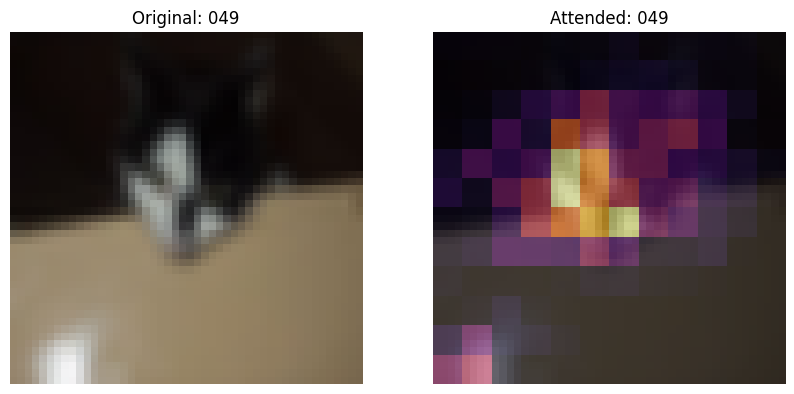

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9878 - loss: 0.0364 - top-5-accuracy: 1.0000 - val_accuracy: 0.8683 - val_loss: 0.5821 - val_top-5-accuracy: 0.9940
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8677 - loss: 0.6166 - top-5-accuracy: 0.9925
Loss: 0.62
Top 1 test accuracy: 86.77%
Top 5 test accuracy: 99.25%


In [12]:
class PatchConvNet(keras.Model):
    def __init__(
        self,
        stem,
        trunk,
        attention_pooling,
        train_augmentation_model=None,
        preprocessing_model=None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.stem = stem
        self.trunk = trunk
        self.attention_pooling = attention_pooling
        self.train_augmentation_model = train_augmentation_model
        self.preprocessing_model = preprocessing_model

    def call(self, x, training=False):
        if training and self.train_augmentation_model is not None:
            x = self.train_augmentation_model(x)
        elif self.preprocessing_model is not None:
            x = self.preprocessing_model(x)

        x = self.stem(x)
        x = self.trunk(x)
        logits, viz_weights = self.attention_pooling(x)
        return logits

train_augmentation_model = get_train_augmentation_model()
preprocessing_model = get_preprocessing()
conv_stem = build_convolutional_stem(dimensions=DIMENSIONS)
conv_trunk = Trunk(depth=TRUNK_DEPTH, dimensions=DIMENSIONS, ratio=SE_RATIO)
attention_pooling = AttentionPooling(dimensions=DIMENSIONS, num_classes=NUM_CLASSES)

patch_conv_net = PatchConvNet(
    stem=conv_stem,
    trunk=conv_trunk,
    attention_pooling=attention_pooling,
    train_augmentation_model=train_augmentation_model,
    preprocessing_model=preprocessing_model,
)


train_callbacks = [TrainMonitor(epoch_interval=5)]

optimizer = keras.optimizers.AdamW(
    learning_rate=scheduled_lrs, weight_decay=WEIGHT_DECAY
)

patch_conv_net.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)
history = patch_conv_net.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=train_callbacks,
)


loss, acc_top1, acc_top5 = patch_conv_net.evaluate(test_ds)
print(f"Loss: {loss:0.2f}")
print(f"Top 1 test accuracy: {acc_top1*100:0.2f}%")
print(f"Top 5 test accuracy: {acc_top5*100:0.2f}%")

      0/Unknown 0s 0s/step

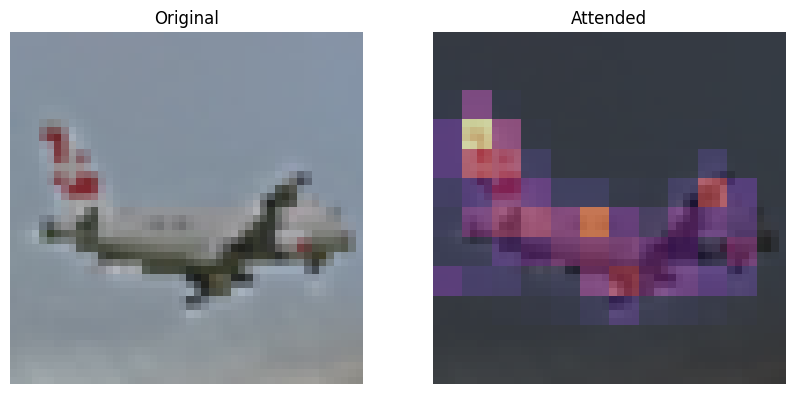

In [13]:
def plot_attention(image):


    image = ops.image.resize(image, (32, 32))
    image = image[np.newaxis, ...]
    test_augmented_images = patch_conv_net.preprocessing_model(image)

    test_x = patch_conv_net.stem(test_augmented_images)

    test_x = patch_conv_net.trunk(test_x)

    _, test_viz_weights = patch_conv_net.attention_pooling(test_x)
    test_viz_weights = test_viz_weights[np.newaxis, ...]

    num_patches = ops.shape(test_viz_weights)[-1]
    height = width = int(math.sqrt(num_patches))
    test_viz_weights = layers.Reshape((height, width))(test_viz_weights)
    selected_image = test_augmented_images[0]
    selected_weight = test_viz_weights[0]

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].imshow(selected_image)
    ax[0].set_title(f"Original")
    ax[0].axis("off")
    img = ax[1].imshow(selected_image)
    ax[1].imshow(selected_weight, cmap="inferno", alpha=0.6, extent=img.get_extent())
    ax[1].set_title(f"Attended")
    ax[1].axis("off")
    plt.axis("off")
    plt.show()
    plt.close()


url = "http://farm9.staticflickr.com/8017/7140384795_385b1f48df_z.jpg"
image_name = keras.utils.get_file(fname="image.jpg", origin=url)
image = keras.utils.load_img(image_name)
image = keras.utils.img_to_array(image)
plot_attention(image)